In [48]:
! python seq_saliency_full_chromosome_HOCOMOCO.py \
    --model /mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/hESC_universal_5kb_8_tracks_KO_fix_mask.ckpt \
    --chr chr20 \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --bigwigs ctcf=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/ctcf.bw \
              atac=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/atac.bw \
    --resolution 4096 \
    --matrix-size 512 \
    --motif-score-threshold 3.0 \
    --meme-file /home/dmp131/C.Shark/src/cshark/static/HOCOMOCOv11_full_HUMAN_mono_meme_format.meme \
    --out-file outputs/chr20_attribution.bw

Using device: cuda
Processing chr20 with length 63025520...
Processing chromosome windows: 100%|████████████| 59/59 [01:37<00:00,  1.66s/it]
Averaging scores from overlapping windows...
Saving chromosome-wide attribution scores...
Successfully saved attribution scores to outputs/chr20_attribution.bw
Scanning for motifs across the entire chromosome...
Successfully parsed 769 motifs from /home/dmp131/C.Shark/src/cshark/static/HOCOMOCOv11_full_HUMAN_mono_meme_format.meme
Moving gradients to GPU for motif scanning...
Scanning motifs on GPU: 100%|█████████████████| 769/769 [04:24<00:00,  2.91it/s]
Found 33547473 motif occurrences above the score threshold.
Saved motif scanning results to outputs/chr20_attribution_motifs.tsv

Top 40 motifs correlated with saliency scores:
                          motif       pos  score_max
29639500  ZBT14_HUMAN.H11MO.0.C   5730968  58.594009
4459190    E2F2_HUMAN.H11MO.0.B   5730967  56.322754
4867186    E2F5_HUMAN.H11MO.0.B   5730969  54.338711
29639657  Z

In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [50]:
df = pd.read_csv('outputs/chr20_attribution_motifs.tsv', sep='\t')
df

,motif,pos,score_fw,score_rc,score_max,pos_100bp
0,AHR_HUMAN.H11MO.0.B,86540,-0.828544,3.272568,3.272568,86500
1,AHR_HUMAN.H11MO.0.B,154080,-0.187988,3.094190,3.094190,154000
2,AHR_HUMAN.H11MO.0.B,174556,-0.628074,3.841735,3.841735,174500
3,AHR_HUMAN.H11MO.0.B,327696,1.265047,-3.742059,3.742059,327600
4,AHR_HUMAN.H11MO.0.B,327737,1.711247,-4.529254,4.529254,327700
...,...,...,...,...,...,...
3684827,ZSCA4_HUMAN.H11MO.0.D,62807987,3.766674,1.864922,3.766674,62807900
3684828,ZSCA4_HUMAN.H11MO.0.D,62808049,5.590952,6.638797,6.638797,62808000
3684829,ZSCA4_HUMAN.H11MO.0.D,62808107,5.105896,1.228224,5.105896,62808100
3684830,ZSCA4_HUMAN.H11MO.0.D,62808882,4.777499,2.433276,4.777499,62808800


In [51]:
# score is whichever has greatest absolute value
df['score'] = df[['score_fw', 'score_rc']].apply(lambda x: x['score_fw'] if abs(x['score_fw']) >= abs(x['score_rc']) else x['score_rc'], axis=1)

In [52]:
df

,motif,pos,score_fw,score_rc,score_max,pos_100bp,score
0,AHR_HUMAN.H11MO.0.B,86540,-0.828544,3.272568,3.272568,86500,3.272568
1,AHR_HUMAN.H11MO.0.B,154080,-0.187988,3.094190,3.094190,154000,3.094190
2,AHR_HUMAN.H11MO.0.B,174556,-0.628074,3.841735,3.841735,174500,3.841735
3,AHR_HUMAN.H11MO.0.B,327696,1.265047,-3.742059,3.742059,327600,-3.742059
4,AHR_HUMAN.H11MO.0.B,327737,1.711247,-4.529254,4.529254,327700,-4.529254
...,...,...,...,...,...,...,...
3684827,ZSCA4_HUMAN.H11MO.0.D,62807987,3.766674,1.864922,3.766674,62807900,3.766674
3684828,ZSCA4_HUMAN.H11MO.0.D,62808049,5.590952,6.638797,6.638797,62808000,6.638797
3684829,ZSCA4_HUMAN.H11MO.0.D,62808107,5.105896,1.228224,5.105896,62808100,5.105896
3684830,ZSCA4_HUMAN.H11MO.0.D,62808882,4.777499,2.433276,4.777499,62808800,4.777499


In [53]:
# keep only most positive and most negative attributions per position (pos_100bp)
df_top_pos = df.groupby('pos_100bp').apply(lambda x: x.loc[x['score'].abs().idxmax()]).reset_index(drop=True)
df_top_neg = df.groupby('pos_100bp').apply(lambda x: x.loc[x['score'].abs().idxmin()]).reset_index(drop=True)
df_top = pd.concat([df_top_pos, df_top_neg])
df_top.sort_values('pos_100bp', inplace=True)
df_top

/tmp/ipykernel_3914127/3803176119.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_top_pos = df.groupby('pos_100bp').apply(lambda x: x.loc[x['score'].abs().idxmax()]).reset_index(drop=True)
/tmp/ipykernel_3914127/3803176119.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_top_neg = df.groupby('pos_100bp').apply(lambda x: x.loc[x['score'].abs().idxmin()]).reset_index(drop=True)


,motif,pos,score_fw,score_rc,score_max,pos_100bp,score
0,ZBT14_HUMAN.H11MO.0.C,73896,-3.510879,-0.003273,3.510879,73800,-3.510879
0,KLF12_HUMAN.H11MO.0.C,73895,-3.043007,0.221377,3.043007,73800,-3.043007
1,EGR4_HUMAN.H11MO.0.D,83790,-0.404055,-3.100656,3.100656,83700,-3.100656
1,EGR4_HUMAN.H11MO.0.D,83790,-0.404055,-3.100656,3.100656,83700,-3.100656
2,ZBT14_HUMAN.H11MO.0.C,84425,-3.134038,0.266189,3.134038,84400,-3.134038
...,...,...,...,...,...,...,...
38444,ZBT14_HUMAN.H11MO.0.C,62899744,-0.610755,3.293274,3.293274,62899700,3.293274
38445,ZBT14_HUMAN.H11MO.0.C,62900568,-0.229595,4.222217,4.222217,62900500,4.222217
38445,AHR_HUMAN.H11MO.0.B,62900568,-0.624322,3.077306,3.077306,62900500,3.077306
38446,E2F2_HUMAN.H11MO.0.B,62900615,0.815614,4.874892,4.874892,62900600,4.874892


In [54]:
df_top['motif'].value_counts().head(25)

motif
ZBT14_HUMAN.H11MO.0.C    27950
MECP2_HUMAN.H11MO.0.C     6285
KLF12_HUMAN.H11MO.0.C     5215
PLAL1_HUMAN.H11MO.0.D     2607
E2F2_HUMAN.H11MO.0.B      1715
EGR4_HUMAN.H11MO.0.D      1411
MYF6_HUMAN.H11MO.0.C      1368
PRRX2_HUMAN.H11MO.0.C     1056
E2F5_HUMAN.H11MO.0.B       844
KLF13_HUMAN.H11MO.0.D      815
KLF8_HUMAN.H11MO.0.C       797
MAZ_HUMAN.H11MO.1.A        775
KLF4_HUMAN.H11MO.0.A       676
AHR_HUMAN.H11MO.0.B        502
UNC4_HUMAN.H11MO.0.D       481
ZBT7A_HUMAN.H11MO.0.A      427
HMGA1_HUMAN.H11MO.0.D      422
SP2_HUMAN.H11MO.1.B        417
GLIS3_HUMAN.H11MO.0.D      369
SOX15_HUMAN.H11MO.0.D      364
GLIS2_HUMAN.H11MO.0.D      340
SP1_HUMAN.H11MO.1.A        329
HIC1_HUMAN.H11MO.0.C       319
ZFHX3_HUMAN.H11MO.0.D      308
DLX2_HUMAN.H11MO.0.D       305
Name: count, dtype: int64

In [55]:
df.sort_values('pos').head(20)

,motif,pos,score_fw,score_rc,score_max,pos_100bp,score
1587853,KLF12_HUMAN.H11MO.0.C,73895,-3.043007,0.221377,3.043007,73800,-3.043007
3245108,ZBT14_HUMAN.H11MO.0.C,73896,-3.510879,-0.003273,3.510879,73800,-3.510879
1864796,MECP2_HUMAN.H11MO.0.C,73897,-1.309218,-3.167913,3.167913,73800,-3.167913
479994,E2F2_HUMAN.H11MO.0.B,73898,-3.144777,-0.437795,3.144777,73800,-3.144777
606209,EGR4_HUMAN.H11MO.0.D,83790,-0.404055,-3.100656,3.100656,83700,-3.100656
3245109,ZBT14_HUMAN.H11MO.0.C,84425,-3.134038,0.266189,3.134038,84400,-3.134038
1587854,KLF12_HUMAN.H11MO.0.C,84426,-3.021417,0.381800,3.021417,84400,-3.021417
479995,E2F2_HUMAN.H11MO.0.B,86477,0.447630,3.250215,3.250215,86400,3.250215
1569641,KAISO_HUMAN.H11MO.1.A,86481,0.081384,3.206836,3.206836,86400,3.206836
1713757,KLF8_HUMAN.H11MO.0.C,86481,0.223869,3.207107,3.207107,86400,3.207107


In [58]:
# find mean effect of each motif
motif_means = df.groupby('motif')[['score_fw', 'score_rc']].mean().reset_index()
motif_means[motif_means['motif'] == 'CTCFL']

,motif,score_fw,score_rc


<Axes: xlabel='score', ylabel='Count'>

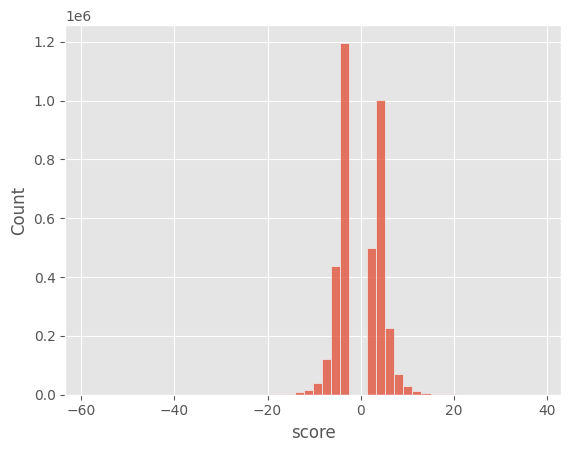

In [59]:
sns.histplot(df['score'], bins=50)

  motif  score_max  score_max_positive  frequency  score_max_negative
0   AHR   4.859483           30.921970      17342          -45.232040
1  AIRE   4.075054           12.440521       1162          -10.653980
2  ALX1   4.392164           26.951656       5882          -15.037311
3  ALX3   4.528326           32.266975      10381          -19.738134
4  ALX4   4.575519           35.214272      12263          -21.285547


([Text(29.408880079177123, 31294.547342937018, 'SP1'),
  Text(33.68606602914873, 29350.0792982045, 'KAISO'),
  Text(39.44249686118097, 26936.33512106088, 'MECP2'),
  Text(30.273521527936396, 26178.6677915643, 'SP2'),
  Text(35.561306305085466, 23179.454487202638, 'E2F2'),
  Text(31.466813997299468, 22768.23571489245, 'MAZ'),
  Text(30.48949216588852, 19505.348703441196, 'EGR4'),
  Text(36.12337608414313, 20239.699550250356, 'PLAL1'),
  Text(-38.11725565464265, 30509.555496456836, 'SP1'),
  Text(-41.4586427150234, 26514.174103659705, 'KAISO'),
  Text(-39.29783557230426, 22504.505754600817, 'MAZ'),
  Text(-41.05147482272116, 20239.699550250356, 'PLAL1')],
  <matplotlib.patches.FancyArrowPatch at 0x7f0e0a93cce0>])

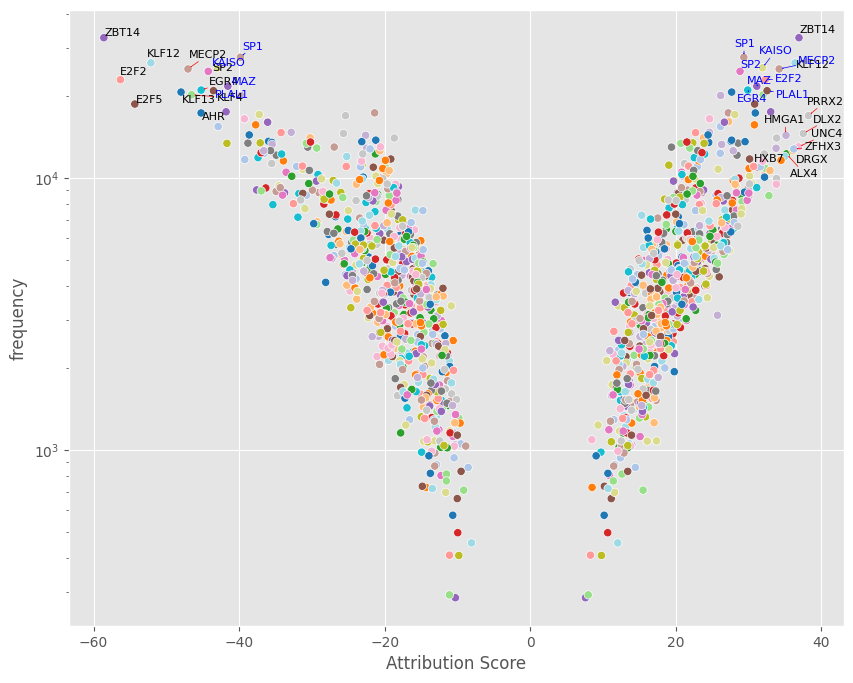

In [60]:
from adjustText import adjust_text

# for each motif plot it's frequency vs average score
# remove suffix from motif name
df['motif'] = df['motif'].apply(lambda x: x.split('.')[0].replace('_HUMAN', ''))
motif_groups = df.groupby('motif')
motif_summary = motif_groups.agg({
    'motif': 'first',
    'score_max': 'mean',
    'score': 'max',
    'pos': 'count'
}).rename(columns={'pos': 'frequency'}).reset_index(drop=True)  
motif_summary_min = motif_groups.agg({
    'motif': 'first',
    'score': 'min',
}).reset_index(drop=True).rename(columns={'score': 'score_min'})    
motif_summary = motif_summary.merge(motif_summary_min[['motif', 'score_min']], on='motif')
motif_summary = motif_summary.rename(columns={'score': 'score_max_positive', 'score_min': 'score_max_negative'})
print(motif_summary.head())
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=motif_summary[motif_summary['score_max_positive'] > 0], x='score_max_positive', y='frequency', 
                hue='motif', palette='tab20',
                ax=ax, legend=False)
sns.scatterplot(data=motif_summary[motif_summary['score_max_negative'] < 0], x='score_max_negative', y='frequency', 
                hue='motif', palette='tab20',
                ax=ax, legend=False)
#ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Attribution Score')
# label the top 10 motifs by in each direction
top_pos = motif_summary.nlargest(10, 'score_max_positive')
top_neg = motif_summary.nsmallest(10, 'score_max_negative')
texts = []
for _, row in top_pos.iterrows():
    txt = ax.text(row['score_max_positive'], row['frequency'], row['motif'], fontsize=8)
    texts.append(txt)
for _, row in top_neg.iterrows():
    txt = ax.text(row['score_max_negative'], row['frequency'], row['motif'], fontsize=8)
    texts.append(txt)

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='->', color='red'))

# for each side, plot the top 10 by frequency too
top_freq_pos = motif_summary[motif_summary['score_max_positive'] > 0].nlargest(10, 'frequency')
top_freq_neg = motif_summary[motif_summary['score_max_negative'] < 0].nlargest(10, 'frequency')
# remove any already labeled
top_freq_pos = top_freq_pos[~top_freq_pos['motif'].isin(top_pos['motif'])]
top_freq_neg = top_freq_neg[~top_freq_neg['motif'].isin(top_neg['motif'])]
texts = []
for _, row in top_freq_pos.iterrows():
    txt = ax.text(row['score_max_positive'], row['frequency'], row['motif'], fontsize=8, color='blue')
    texts.append(txt)
for _, row in top_freq_neg.iterrows():
    txt = ax.text(row['score_max_negative'], row['frequency'], row['motif'], fontsize=8, color='blue')
    texts.append(txt)
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='->', color='blue'))